# Building an accessor - Met Office UKV data
In this tutorial we will demonstrate how to build a simple data accessor for pyearthtools, which is a key building block in a PyEarthTools pipeline. For this example we will use a small sample of Forecast Analysis data from the Met Office , which is available through AWS. Although one can 

In [19]:
import warnings
warnings.filterwarnings("ignore")

In [1]:
import pathlib
import functools
import datetime

In [2]:
import matplotlib.pyplot
import cartopy
import numpy

In [3]:
import xarray

In [4]:
import h5py

### Exploring data
Let's start by looking at the data we are going to load.  A number of [Met Office Datasets](https://www.metoffice.gov.uk/services/data/external-data-channels) are available through third-party sources such as AWS and Snowflake. In this example we will look at loading some of UK high-resolution analysis data from AWS.

Links:
* [Met Office Data on Thiurd-party platforms](Links:https://www.metoffice.gov.uk/services/data/external-data-channels)
* [Met Office UKV data documentation](https://www.metoffice.gov.uk/api/assets/file/ukv-2km-ps47-asdi-pdf-updatespdf?prefix=assets)
* [UKV on AWS Sustainable Data Initiative](https://registry.opendata.aws/met-office-uk-deterministic/)
* [Contents of AWS S3 bucket for MO UKV data](https://met-office-atmospheric-model-data.s3.eu-west-2.amazonaws.com/index.html#uk-deterministic-2km/)

In [5]:
ukv_humidity_sample_ds = xarray.open_dataset(
    's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260111T1200Z/20260111T1200Z-PT0000H00M-relative_humidity_on_pressure_levels.nc',
    # engine="netcdf4",
    engine="h5netcdf",
    storage_options={"anon": True},
)

/tmp/ipykernel_2648/1690480363.py:1: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ukv_humidity_sample_ds = xarray.open_dataset(


In [6]:
ukv_humidity_sample_ds

<xarray.Dataset> Size: 167MB
Dimensions:                       (pressure: 33, projection_y_coordinate: 970,
                                   projection_x_coordinate: 1042, bnds: 2)
Coordinates:
  * pressure                      (pressure) float32 132B 1e+05 ... 1e+03
  * projection_y_coordinate       (projection_y_coordinate) float32 4kB -1.03...
  * projection_x_coordinate       (projection_x_coordinate) float32 4kB -1.15...
    flag                          (pressure, projection_y_coordinate, projection_x_coordinate) int8 33MB ...
    forecast_period               timedelta64[ns] 8B ...
    forecast_reference_time       datetime64[ns] 8B ...
    time                          datetime64[ns] 8B ...
Dimensions without coordinates: bnds
Data variables:
    relative_humidity             (pressure, projection_y_coordinate, projection_x_coordinate) float32 133MB ...
    lambert_azimuthal_equal_area  int32 4B ...
    projection_y_coordinate_bnds  (projection_y_coordinate, bnds) float32 8kB ...
    projection_x_coordinate_bnds  (projection_x_coordinate, bnds) float32 8kB ...
Attributes:
    history:                      2026-01-11T13:03:57Z: StaGE Decoupler
    institution:                  Met Office
    mosg__forecast_run_duration:  PT54H
    mosg__grid_domain:            uk_extended
    mosg__grid_type:              standard
    mosg__grid_version:           1.7.0
    mosg__model_configuration:    uk_det
    source:                       Met Office Unified Model
    title:                        UKV Model Forecast on UK 2 km Standard Grid
    um_version:                   13.1
    Conventions:                  CF-1.7, UKMO-1.0

In [7]:
ukv_humidity_sample_ds.pressure

<xarray.DataArray 'pressure' (pressure: 33)> Size: 132B
array([100000.,  97500.,  95000.,  92500.,  90000.,  85000.,  80000.,  75000.,
        70000.,  65000.,  60000.,  55000.,  50000.,  45000.,  40000.,  37500.,
        35000.,  32500.,  30000.,  27500.,  25000.,  22500.,  20000.,  17500.,
        15000.,  12500.,  10000.,   7000.,   5000.,   4000.,   3000.,   2000.,
         1000.], dtype=float32)
Coordinates:
  * pressure                 (pressure) float32 132B 1e+05 9.75e+04 ... 1e+03
    forecast_period          timedelta64[ns] 8B ...
    forecast_reference_time  datetime64[ns] 8B ...
    time                     datetime64[ns] 8B ...
Attributes:
    axis:       Z
    units:      Pa
    long_name:  pressure
    positive:   down

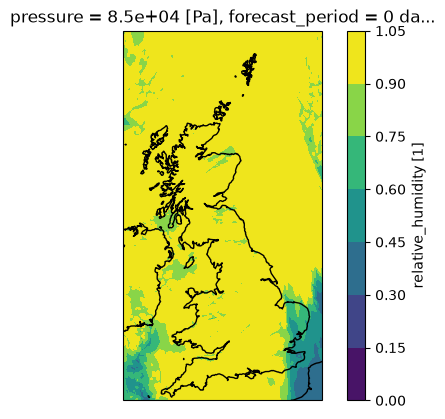

In [8]:
fig1 = matplotlib.pyplot.figure()
ax1 = fig1.add_subplot(1,1,1,projection=cartopy.crs.OSGB() )
# ax1 = fig1.add_subplot(1,1,1,projection=cartopy.crs.Orthographic(-2, 55) )
ukv_humidity_sample_ds.sel({'pressure':85000})['relative_humidity'].plot.contourf(
    ax=ax1,
    transform=cartopy.crs.LambertAzimuthalEqualArea(central_latitude=54.9, central_longitude=-2.5, false_easting=0.0, false_northing=0.0)
)
ax1.coastlines()

### Create a larger dataset from multiple files

In [9]:
dt_list = [datetime.datetime(2026,6,1,0,0) + ix1 * datetime.timedelta(hours=12) for ix1 in range(20)]

In [11]:
var_list = [
    'wind_direction_on_pressure_levels',
    'wind_speed_on_pressure_levels',
    'temperature_on_pressure_levels',
    'relative_humidity_on_pressure_levels',
]

In [12]:
vt_template= '{dt.year:04d}{dt.month:02d}{dt.day:02d}T{dt.hour:02d}{dt.minute:02d}Z'

In [29]:
ukv_path_list = [
    's3://met-office-atmospheric-model-data/uk-deterministic-2km/{vt_str}/{vt_str}-PT0000H00M-{var_name}.nc'.format(
        vt_str=vt_template.format(dt=current_dt),
        var_name=current_var,
    )
    # for current_dt in dt_list for current_var in ['temperature_on_pressure_levels']
    for current_dt in dt_list for current_var in var_list
]

In [30]:
ukv_path_list

['s3://met-office-atmospheric-model-data/uk-deterministic-2km/20260601T0000Z/20260601T0000Z-PT0000H00M-wind_direction_on_pressure_levels.nc',
 's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260601T0000Z/20260601T0000Z-PT0000H00M-wind_speed_on_pressure_levels.nc',
 's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260601T0000Z/20260601T0000Z-PT0000H00M-temperature_on_pressure_levels.nc',
 's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260601T0000Z/20260601T0000Z-PT0000H00M-relative_humidity_on_pressure_levels.nc',
 's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260601T1200Z/20260601T1200Z-PT0000H00M-wind_direction_on_pressure_levels.nc',
 's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260601T1200Z/20260601T1200Z-PT0000H00M-wind_speed_on_pressure_levels.nc',
 's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260601T1200Z/20260601T1200Z-PT0000H00M-temperature_on_pressure_levels.nc',
 's3://met-office

In [31]:
ukv_sample_ds = xarray.open_mfdataset(
    ukv_path_list,
    # engine="netcdf4",
    engine="h5netcdf",
    storage_options={"anon": True},
    concat_dim='time',
    combine='nested',
)

In [32]:
ukv_sample_ds

<xarray.Dataset> Size: 45GB
Dimensions:                       (time: 80, pressure: 33,
                                   projection_y_coordinate: 970,
                                   projection_x_coordinate: 1042, bnds: 2)
Coordinates:
  * time                          (time) datetime64[ns] 640B 2026-06-01 ... 2...
    forecast_reference_time       (time) datetime64[ns] 640B 2026-06-01 ... 2...
  * pressure                      (pressure) float32 132B 1e+05 ... 1e+03
  * projection_y_coordinate       (projection_y_coordinate) float32 4kB -1.03...
  * projection_x_coordinate       (projection_x_coordinate) float32 4kB -1.15...
    forecast_period               timedelta64[ns] 8B 00:00:00
Dimensions without coordinates: bnds
Data variables:
    wind_from_direction           (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 11GB dask.array<chunksize=(1, 1, 128, 128), meta=np.ndarray>
    lambert_azimuthal_equal_area  (time) int32 320B -2147483647 ... -2147483647
    projection_y_coordinate_bnds  (time, projection_y_coordinate, bnds) float32 621kB dask.array<chunksize=(1, 970, 2), meta=np.ndarray>
    projection_x_coordinate_bnds  (time, projection_x_coordinate, bnds) float32 667kB dask.array<chunksize=(1, 1042, 2), meta=np.ndarray>
    flag                          (time, pressure, projection_y_coordinate, projection_x_coordinate) int8 3GB dask.array<chunksize=(1, 17, 485, 521), meta=np.ndarray>
    wind_speed                    (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 11GB dask.array<chunksize=(1, 1, 128, 128), meta=np.ndarray>
    air_temperature               (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 11GB dask.array<chunksize=(1, 1, 128, 128), meta=np.ndarray>
    relative_humidity             (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 11GB dask.array<chunksize=(1, 1, 128, 128), meta=np.ndarray>
Attributes:
    ancillary_variables:          flag
    history:                      2026-06-01T01:22:48Z: StaGE Decoupler
    institution:                  Met Office
    mosg__forecast_run_duration:  PT54H
    mosg__grid_domain:            uk_extended
    mosg__grid_type:              standard
    mosg__grid_version:           1.7.0
    mosg__model_configuration:    uk_det
    source:                       Met Office Unified Model
    title:                        UKV Model Forecast on UK 2 km Standard Grid
    um_version:                   13.8
    Conventions:                  CF-1.7, UKMO-1.0

In [ ]:
!export VARS="wind_direction_on_pressure_levels wind_speed_on_pressure_levels temperature_on_pressure_levels relative_humidity_on_pressure_levels"; for var1 in ${VARS}; do for vt_date in {20260101..20260111} ; do for vt_time in 0000 1200;  do  aws s3 cp --no-sign-request s3://met-office-atmospheric-model-data/uk-deterministic-2km/${vt_date}T${vt_time}Z/${vt_date}T${vt_time}Z-PT0000H00M-${var1}.nc /gws/ssde/j25b/mohc_shared/dscop/mo_ukv_aws/; done; done; done


### Create PyEarthTools Accessor

In [38]:
import pyearthtools

In [35]:
from pyearthtools.data import Petdt
from pyearthtools.data.indexes import ArchiveIndex
from pyearthtools.data.transforms import Transform, TransformCollection
from pyearthtools.data.archive import register_archive

In [36]:
class MO_UKV(ArchiveIndex):
    """
    """
    MO_UKV_AWS_ROOT_PATH = 's3://met-office-atmospheric-model-data/uk-deterministic-2km/'
    MO_UKV_PATH_TEMPLATE = MO_UKV_AWS_ROOT_PATH + '{vt_str}/{vt_str}-PT0000H00M-{var_name}.nc'
    
    def __init__(
        self,
        variables: list[str] | str,
        *,
        transforms: Transform | TransformCollection | None = None,
    ):
        """
        Init function for Merra2 accessor base class.
        """
        self._variables = variables
        super_transforms = TransformCollection([pyearthtools.data.transforms.variables.Trim(self._variables),]) + transforms
        
        # call the base class
        super().__init__(
            transforms=super_transforms,
        )
        self.record_initialisation()

    def filesystem(
        self,
        querytime: str | Petdt,
    ) -> pathlib.Path | dict[str, str | pathlib.Path]:
        

        querytime = Petdt(querytime)
        paths = []
        
        
        for var_name in self._variables:
            try:
                paths += [
                    MO_UKV.MO_UKV_PATH_TEMPLATE.format(
                        vt_str=vt_template.format(dt=querytime),
                        var_name=var_name,
                    )
                ]
            except KeyError:
                print(f'Non data for var {var_name}')
        
        print(paths)
        return paths
        
    def __desc__(self):
        return {
            "singleline": "Met Office UKV Forecast Analysis ",
            "range": "June 2026",
            "Documentation": "https://registry.opendata.aws/met-office-uk-deterministic/",
        }

    

In [39]:
ukv_accessor = MO_UKV(var_list)

In [40]:
ukv_accessor['2026-06-01 12:00']

['s3://met-office-atmospheric-model-data/uk-deterministic-2km/20260601T1200Z/20260601T1200Z-PT0000H00M-wind_direction_on_pressure_levels.nc', 's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260601T1200Z/20260601T1200Z-PT0000H00M-wind_speed_on_pressure_levels.nc', 's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260601T1200Z/20260601T1200Z-PT0000H00M-temperature_on_pressure_levels.nc', 's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260601T1200Z/20260601T1200Z-PT0000H00M-relative_humidity_on_pressure_levels.nc']


curl error details: 


DataNotFoundError: Data with args: (Petdt('2026-06-01T12:00'),) could not be found.